In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("german_credit_data.csv")
df.head(5)

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [5]:
df.isna().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df =df.dropna().reset_index(drop=True)

In [9]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [11]:
df.drop(columns="Unnamed: 0", inplace= True)

In [12]:
df


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,53,male,2,free,little,little,4870,24,car,bad
3,35,male,3,rent,little,moderate,6948,36,car,good
4,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...
517,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,40,male,3,own,little,little,3857,30,car,good
520,23,male,2,free,little,little,1845,45,radio/TV,bad


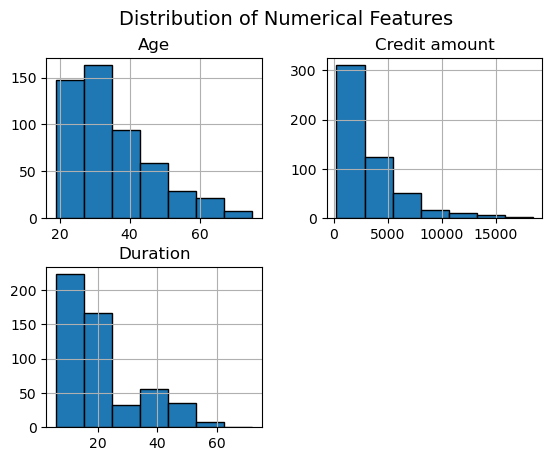

In [14]:
df[["Age", "Credit amount", "Duration"]].hist(bins=7, edgecolor="black")
plt.suptitle("Distribution of Numerical Features", fontsize=14)
plt.show()

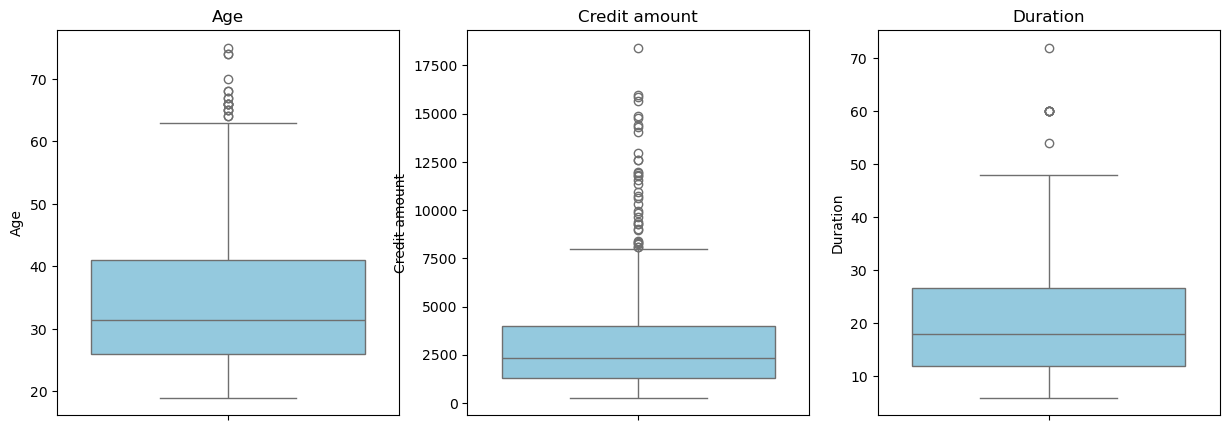

In [15]:
plt.figure(figsize=(15, 5))
for i, col in enumerate (["Age", "Credit amount", "Duration"]):
    plt.subplot(1,3,i+1)
    sns.boxplot(y=df[col], color="skyblue")
    plt.title(col)

plt.tight_layout
plt.show()


In [16]:
df.query("Duration>=60")

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
18,63,male,2,own,little,little,6836,60,business,bad
176,24,female,3,own,moderate,moderate,7408,60,car,bad
199,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
358,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad
378,27,male,3,own,little,moderate,14027,60,car,bad
489,42,male,2,free,little,moderate,6288,60,education,bad
507,36,male,2,rent,little,little,7297,60,business,bad


In [18]:
categorical_cols=["Sex", "Job", "Housing", "Saving accounts", "Checking account", "Purpose"]


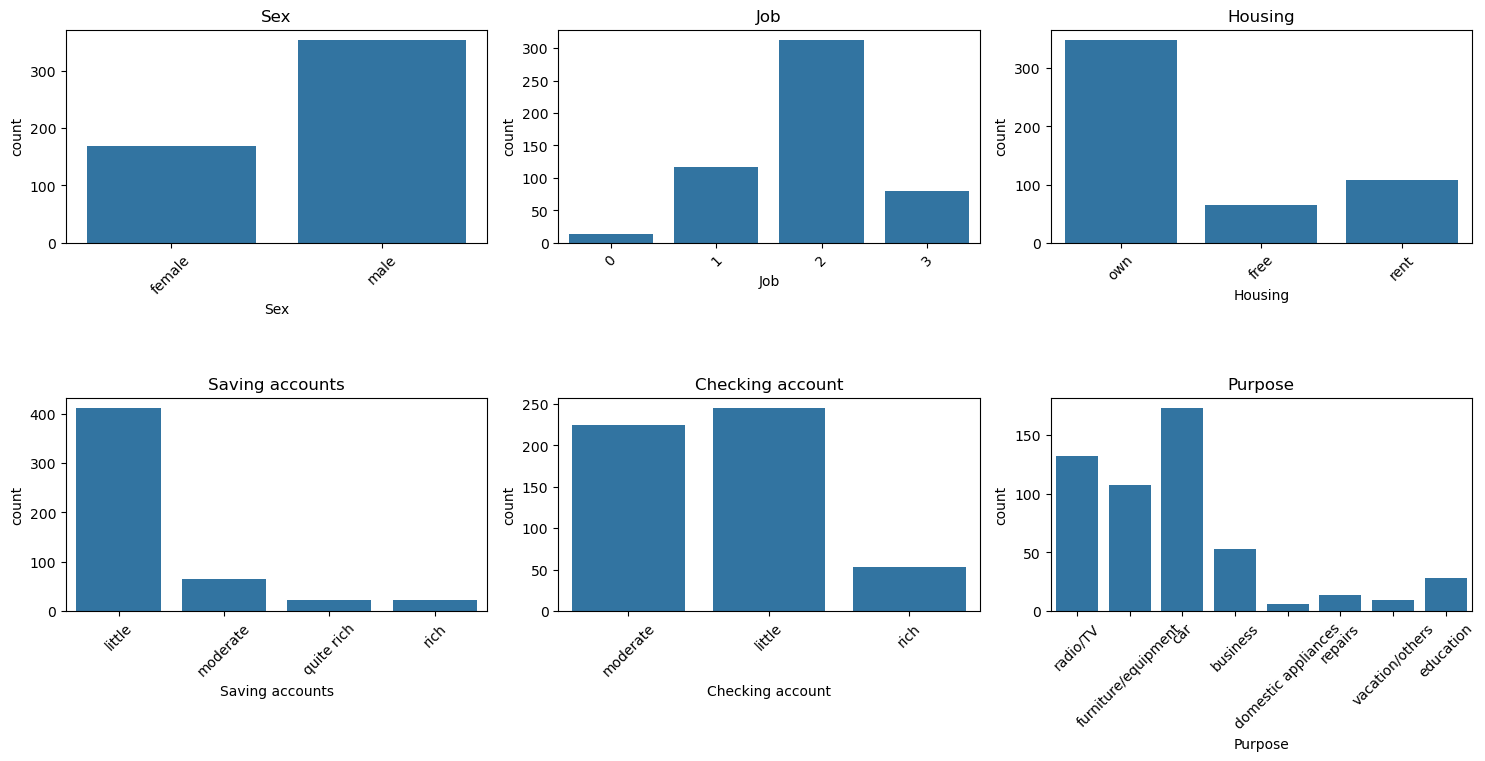

In [20]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i + 1)
    sns.countplot(x=col, data=df)
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [21]:
corr= df[["Age", "Job", "Credit amount", "Duration"]].corr()

In [22]:
corr

,Age,Job,Credit amount,Duration
Age,1.000000,0.039771,0.082014,0.001549
Job,0.039771,1.000000,0.334721,0.200794
Credit amount,0.082014,0.334721,1.000000,0.613298
Duration,0.001549,0.200794,0.613298,1.000000


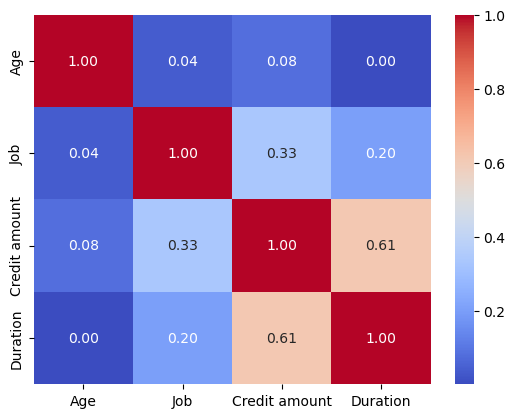

In [23]:
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

In [24]:
df.groupby("Job")["Credit amount"].mean()

Job
0    1767.857143
1    2250.715517
2    3129.130990
3    5648.784810
Name: Credit amount, dtype: float64

In [25]:
df.groupby("Sex")["Credit amount"].mean()

Sex
female    2937.202381
male      3440.833333
Name: Credit amount, dtype: float64

Sex
female    2937.202381
male      3440.833333
Name: Credit amount, dtype: float64

In [27]:
pd.pivot_table(df, values="Credit amount", index= "Housing", columns="Purpose")

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4705.000000,5180.314286,NaN,5314.250000,4419.444444,2097.000000,1190.0,7842.666667
own,3725.973684,3120.485437,1333.5,2625.076923,3031.100000,2307.613861,2993.5,10321.833333
rent,6180.833333,3398.285714,NaN,2627.857143,2890.285714,2138.000000,2384.0,NaN


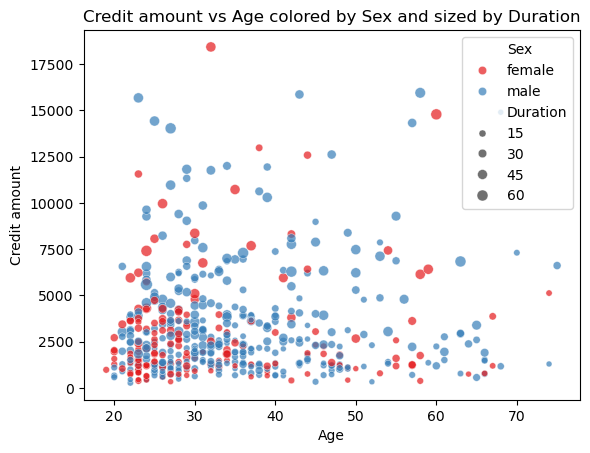

In [29]:
sns.scatterplot(data=df, x="Age", y= "Credit amount", hue="Sex", size="Duration", alpha= 0.7, palette="Set1")
plt.title("Credit amount vs Age colored by Sex and sized by Duration")
plt.show()

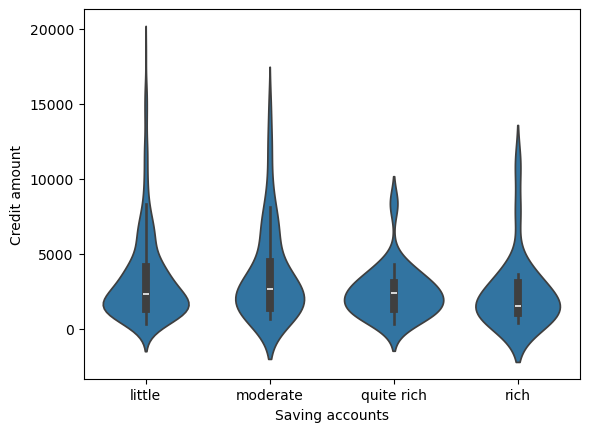

In [31]:
sns.violinplot(data=df, x="Saving accounts", y="Credit amount")
plt.show()

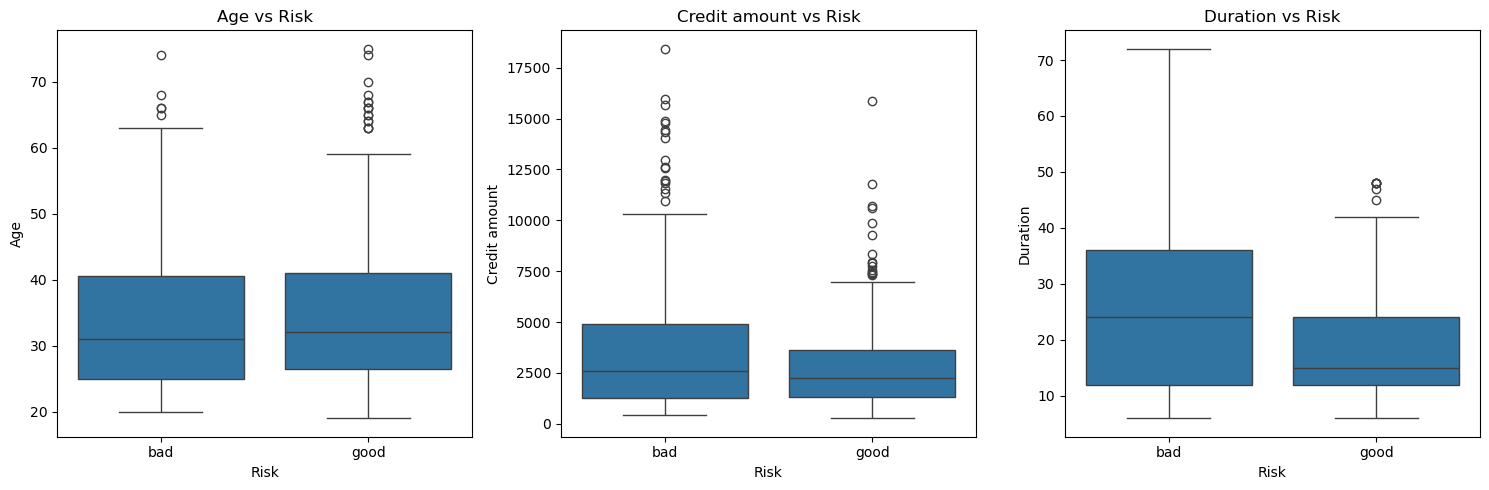

In [32]:
plt.figure(figsize=(15, 5))

for i, col in enumerate(["Age", "Credit amount", "Duration"]):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(data=df, x="Risk", y=col)
    plt.title(f"{col} vs Risk")

plt.tight_layout()
plt.show()

In [33]:
df.groupby("Risk")[["Age", "Credit amount", "Duration"]].mean()

,Age,Credit amount,Duration
Risk,,,
bad,34.147186,3881.090909,25.445887
good,35.477663,2800.594502,18.079038


In [34]:
categorical_cols

['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

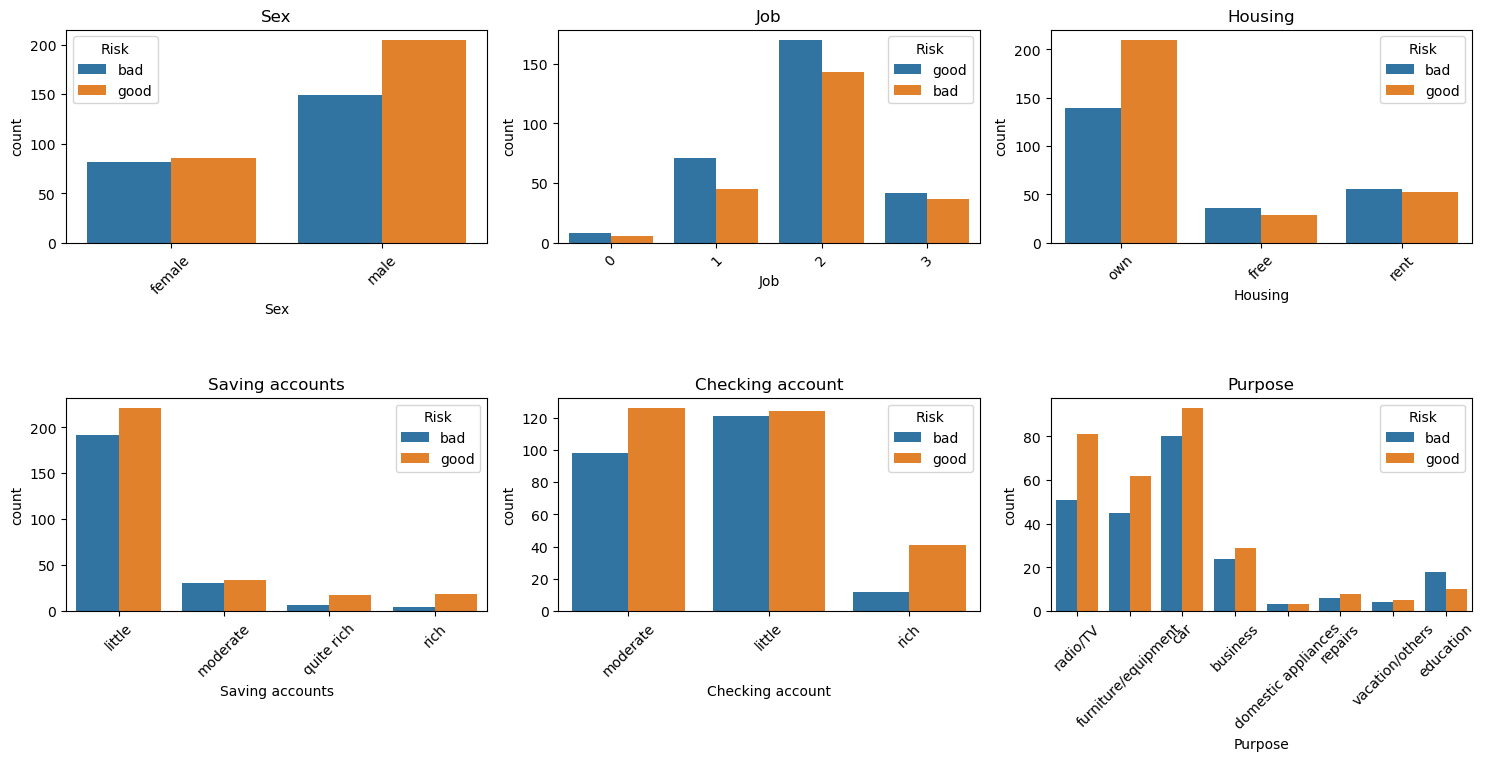

In [38]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i + 1)
    sns.countplot(data=df, x=col, hue="Risk")
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [39]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk', 'Risk_Label'],
      dtype='object')

In [40]:
features= ["Age","Sex", "Job", "Housing", "Saving accounts", "Checking account", "Credit amount", "Duration"]
target="Risk"

In [41]:
df_model = df[features+[target]].copy()

In [42]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,female,2,own,little,moderate,5951,48,bad
1,45,male,2,free,little,little,7882,42,good
2,53,male,2,free,little,little,4870,24,bad
3,35,male,3,rent,little,moderate,6948,36,good
4,28,male,3,own,little,moderate,5234,30,bad


In [43]:
from sklearn.preprocessing import LabelEncoder
import joblib

In [44]:
cat_cols = df_model.select_dtypes(include= "object").columns.drop("Risk")

In [45]:
le_dict={}

In [46]:
cat_cols

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account'], dtype='object')

In [48]:
for col in cat_cols:
    le= LabelEncoder()
    df_model[col]=le.fit_transform(df_model[col])
    le_dict[col]= le
    joblib.dump(le, f"{col}_encoder.pkl")

In [49]:
le_target = LabelEncoder()

In [50]:
df_model[target] = le_target.fit_transform(df_model[target])
df_model[target]

0      0
1      1
2      0
3      1
4      0
      ..
517    1
518    1
519    1
520    0
521    1
Name: Risk, Length: 522, dtype: int64

In [51]:
df_model[target].value_counts()

Risk
1    291
0    231
Name: count, dtype: int64

In [52]:
joblib.dump(le_target, "target_encoder.pkl")

['target_encoder.pkl']

In [53]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,0,2,1,0,1,5951,48,0
1,45,1,2,0,0,0,7882,42,1
2,53,1,2,0,0,0,4870,24,0
3,35,1,3,2,0,1,6948,36,1
4,28,1,3,1,0,1,5234,30,0


In [54]:
from sklearn.model_selection import train_test_split

In [55]:
X= df_model.drop(target, axis =1)
X

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration
0,22,0,2,1,0,1,5951,48
1,45,1,2,0,0,0,7882,42
2,53,1,2,0,0,0,4870,24
3,35,1,3,2,0,1,6948,36
4,28,1,3,1,0,1,5234,30
...,...,...,...,...,...,...,...,...
517,48,1,1,1,0,1,1743,24
518,30,1,3,1,0,0,3959,36
519,40,1,3,1,0,0,3857,30
520,23,1,2,0,0,0,1845,45


In [56]:
y= df_model[target]
y

0      0
1      1
2      0
3      1
4      0
      ..
517    1
518    1
519    1
520    0
521    1
Name: Risk, Length: 522, dtype: int64

In [57]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify= y, random_state= 1)

In [58]:
x_train.shape

(417, 8)

In [59]:
x_test.shape

(105, 8)

In [66]:
import sys
!{sys.executable} -m pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 1.0/101.7 MB 6.9 MB/s eta 0:00:15
    --------------------------------------- 1.8/101.7 MB 4.6 MB/s eta 0:00:22
   - -------------------------------------- 2.6/101.7 MB 4.1 MB/s eta 0:00:24
   - -------------------------------------- 3.4/101.7 MB 4.2 MB/s eta 0:00:24
   - -------------------------------------- 3.9/101.7 MB 3.6 MB/s eta 0:00:28
   -- ------------------------------------- 5.2/101.7 MB 4.0 MB/s eta 0:00:25
   -- ------------------------------------- 5.8/101.7 MB 4.0 MB/s eta 0:00:25
   -- ------------------------------------- 6.8/101.7 MB 3.8 MB/s eta 0:00:26
   -- ------------------------------------- 7.3/101.7 MB 3.7 MB/s eta 0:00:26
   --- ------------------------------------ 7.9/101.7 MB 3.6 MB/s eta 0:00:27


In [67]:
import xgboost

In [68]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [69]:
def train_model(model, param_grid,x_train, y_train, x_test, y_test):
    grid= GridSearchCV(model, param_grid, cv=5, scoring= "accuracy", n_jobs=-1)
    grid.fit(x_train, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    return best_model, acc, grid.best_params_

In [70]:
dt=DecisionTreeClassifier(random_state= 1, class_weight = "balanced")
dt_param_grid = {
    "max_depth": [3,5,7,10,None],
    "min_samples_split" : [2, 5, 10], 
    "min_samples_leaf" : [1, 2, 4]
}

In [71]:
best_dt, acc_dt, params_dt = train_model(dt, dt_param_grid,  x_train, y_train, x_test, y_test)

In [72]:
print("Decision Tree Accuracy", acc_dt)

Decision Tree Accuracy 0.580952380952381


In [73]:
print("Best parameters", params_dt)

Best parameters {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [74]:
rf= RandomForestClassifier(random_state = 1, class_weight = "balanced", n_jobs =-1)


In [75]:
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth" : [5, 7, 10, None],
    "min_samples_split":[2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [76]:
best_rf, acc_rf, params_rf= train_model(rf, rf_param_grid, x_train, y_train, x_test, y_test)


In [77]:
print("Random forest accuracy ", acc_rf)

Random forest accuracy  0.6190476190476191


In [78]:
print("Random forest accuracy ", acc_rf)

Random forest accuracy  0.6190476190476191


In [79]:
print("best params",    params_rf)

best params {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}


In [80]:
et = ExtraTreesClassifier(random_state=1, class_weight="balanced", n_jobs= -1)

In [81]:
et_param_grid = {
    "n_estimators": [100, 200],
    "max_depth" : [5, 7, 10, None],
    "min_samples_split":[2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}


In [82]:
best_et, acc_et, params_et= train_model(et, et_param_grid, x_train, y_train, x_test, y_test)


In [83]:
print("Extra Tree Accuracy:", acc_et)

Extra Tree Accuracy: 0.6476190476190476


In [84]:
print("Best Params", params_et)

Best Params {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


In [85]:
xgb = XGBClassifier(radnom_state= 1, scale_pos_weight = (y_train ==0).sum()/(y_train ==1).sum(), use_label_encoder=False, eval_metric= "logloss")

In [86]:
xgb_param_grid = {
    "n_estimators": [100, 200],
    "max_depth" : [3, 5, 7],
    "learning_rate":[0.01, 0.1, 0.2],
    "subsample": [0.7, 1],
    "colsample_bytree":[0.7, 1]
}

In [95]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=1,
    eval_metric="logloss"
)

In [96]:
best_xgb, acc_xgb, params_xgb = train_model(
    xgb,
    xgb_param_grid,
    x_train,
    y_train,
    x_test,
    y_test
)

In [88]:
print("XGB accuracy", acc_xgb)

XGB accuracy 0.6190476190476191


In [89]:
print("Best params", params_xgb)

Best params {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1}


In [90]:
best_et.predict(x_test)

array([1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1])

In [92]:
joblib.dump(best_et, "extra_trees_credit_model.pkl")

['extra_trees_credit_model.pkl']